In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
data=pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
print(data.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [4]:
X=data[["Sleep Duration", "Physical Activity Level", "Heart Rate", "Daily Steps"]]
y=data["Stress Level"]
print(X.head())
print(y.head())

   Sleep Duration  Physical Activity Level  Heart Rate  Daily Steps
0             6.1                       42          77         4200
1             6.2                       60          75        10000
2             6.2                       60          75        10000
3             5.9                       30          85         3000
4             5.9                       30          85         3000
0    6
1    8
2    8
3    8
4    8
Name: Stress Level, dtype: int64


In [5]:
model=LinearRegression()
model.fit(X, y)

LinearRegression()

In [6]:
y_pred=model.predict(X)
print(y_pred[:5])

[7.09557117 8.96952554 8.96952554 8.76754569 8.76754569]


In [7]:
r2=r2_score(y, y_pred)
print("R2 Score:",r2)

R2 Score: 0.8043986119890252


In [8]:
print("Coefficients:",model.coef_)
print("Intercept:",model.intercept_)

Coefficients: [-1.02197492e+00 -3.10771498e-02  2.13446371e-01  5.10764362e-04]
Intercept: -3.945722408652369


In [9]:
'''prediction=model.predict([[7.5, 60, 72, 8000]])
print("Predicted Stress Level:",prediction[0])'''

'prediction=model.predict([[7.5, 60, 72, 8000]])\nprint("Predicted Stress Level:",prediction[0])'

In [10]:
new_data=pd.DataFrame({"Sleep Duration":[7.5], "Physical Activity Level":[60], "Heart Rate":[72], "Daily Steps":[8000]})
prediction=model.predict(new_data)
print("Predicted Stress Level:",prediction[0])

Predicted Stress Level: 5.9790903077964614


In [11]:
stress=prediction[0]
if stress<3:
    print("Low Stress")
elif stress<6:
    print("Moderate Stress")
else:
    print("High Stress")

Moderate Stress


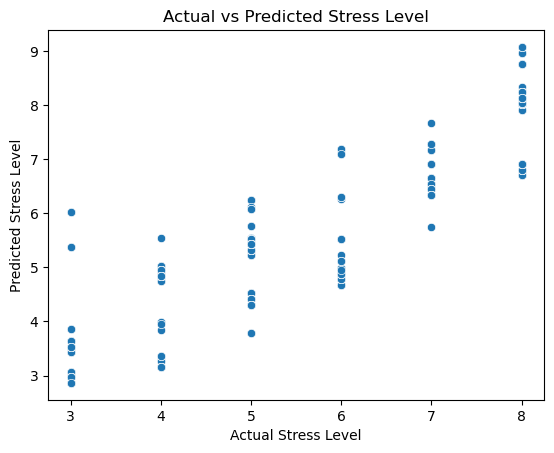

In [12]:
sns.scatterplot(x=y, y=y_pred)
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.title("Actual vs Predicted Stress Level")
plt.show()